In [73]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
#from sklearn.feature_selection import 

In [74]:
data=pd.read_csv("Advertising.csv")

In [75]:
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [76]:
data.iloc[0:20]

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [77]:
data.drop(data.columns[0],axis=1,inplace=True)

In [78]:
data.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [79]:
x=data.iloc[:,:3]
y=data['sales']

In [80]:
x

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [81]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [82]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [83]:
from sklearn.linear_model import LinearRegression

In [84]:
mod=LinearRegression()

In [85]:
mod.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [86]:
y_pred=mod.predict(x_test)

In [87]:
y_pred

array([16.5653963 , 21.18822792, 21.55107058, 10.88923816, 22.20231988,
       13.35556872, 21.19692502,  7.35028523, 13.27547079, 15.12449511,
        9.01443026,  6.52542825, 14.30205991,  8.97026042,  9.45679576,
       12.00454351,  8.91549403, 16.15619251, 10.29582883, 18.72473553,
       19.76821818, 13.77469028, 12.49638908, 21.53501762,  7.60860741,
        5.6119801 , 20.91759483, 11.80627665,  9.08076637,  8.51412012,
       12.17604891,  9.9691939 , 21.73008956, 12.77770578, 18.1011362 ,
       20.07590796, 14.26202556, 20.93826535, 10.83938827,  4.38190607,
        9.51332406, 12.40486324, 10.17045434,  8.09081363, 13.16388427,
        5.2243552 ,  9.28893833, 14.09330719,  8.69024497, 11.66119763,
       15.71848432, 11.63156862, 13.35360735, 11.1531472 ,  6.33636845,
        9.76157954,  9.4195714 , 24.25516546,  7.69519137, 12.15317572])

In [88]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [89]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [90]:
[mae,mse,rmse,r2] #LinearREG

[1.5116692224549084,
 3.7967972367152183,
 np.float64(1.9485372043446383),
 0.8609466508230368]

In [91]:
corr=data.corr(numeric_only=True)
corr


,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

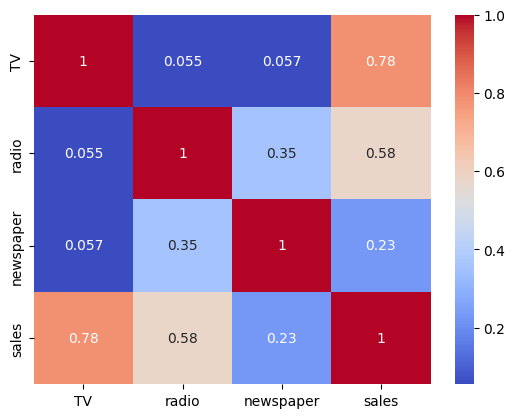

In [92]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [93]:
import statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data=pd.DataFrame()
df=pd.DataFrame(x)

In [94]:
vif_data["feature"]=df.columns
vif_data['VIF']=[variance_inflation_factor(df.values,i) for i in range(len(df.columns))]

In [95]:
vif_data

,feature,VIF
0,TV,2.486772
1,radio,3.285462
2,newspaper,3.055245


In [96]:
data=data.drop("newspaper",axis=1)

In [97]:
data

,TV,radio,sales
0,230.1,37.8,22.1
1,44.5,39.3,10.4
2,17.2,45.9,9.3
3,151.5,41.3,18.5
4,180.8,10.8,12.9
...,...,...,...
195,38.2,3.7,7.6
196,94.2,4.9,9.7
197,177.0,9.3,12.8
198,283.6,42.0,25.5


In [98]:
x2=data.iloc[:,:2]
y2=data['sales']

In [99]:
x2

,TV,radio
0,230.1,37.8
1,44.5,39.3
2,17.2,45.9
3,151.5,41.3
4,180.8,10.8
...,...,...
195,38.2,3.7
196,94.2,4.9
197,177.0,9.3
198,283.6,42.0


In [100]:
x2_train,x2_test,y2_train,y2_test=train_test_split(x2,y2,test_size=0.30,random_state=42)

In [101]:
mod2=LinearRegression()

In [102]:
mod2.fit(x2_train,y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
y2_pred=mod2.predict(x2_test)

In [104]:
mae2=mean_absolute_error(y2_test,y2_pred)
mse2=mean_squared_error(y2_test,y2_pred)
rmse2=np.sqrt(mse)
r22=r2_score(y2_test,y2_pred)

In [105]:
[mae2,mse2,rmse2,r22]

[1.4758950903812145,
 3.6690470545306804,
 np.float64(1.9485372043446383),
 0.8656253548947075]